# Arsenic contamination scenario on Hanoi

In [ ]:
from epyt_flow.data.benchmarks import load_leakdb_scenarios
from epyt_flow.simulation import ScenarioSimulator, EpanetConstants, ScenarioConfig
from epyt_flow.simulation.events import SpeciesInjectionEvent
from epyt_flow.utils import to_seconds

Load scenario :

In [2]:
config, = load_leakdb_scenarios(scenarios_id=["0"], use_net1=False, verbose=False, download_dir="")  #scenarios_id can vary between 0 and 999 
config = ScenarioConfig(scenario_config=config,
                            f_msx_in="arsenic_contamination.msx")

In [3]:
sim = ScenarioSimulator(scenario_config=config)

Explore network :

In [ ]:
sim.plot_topology()

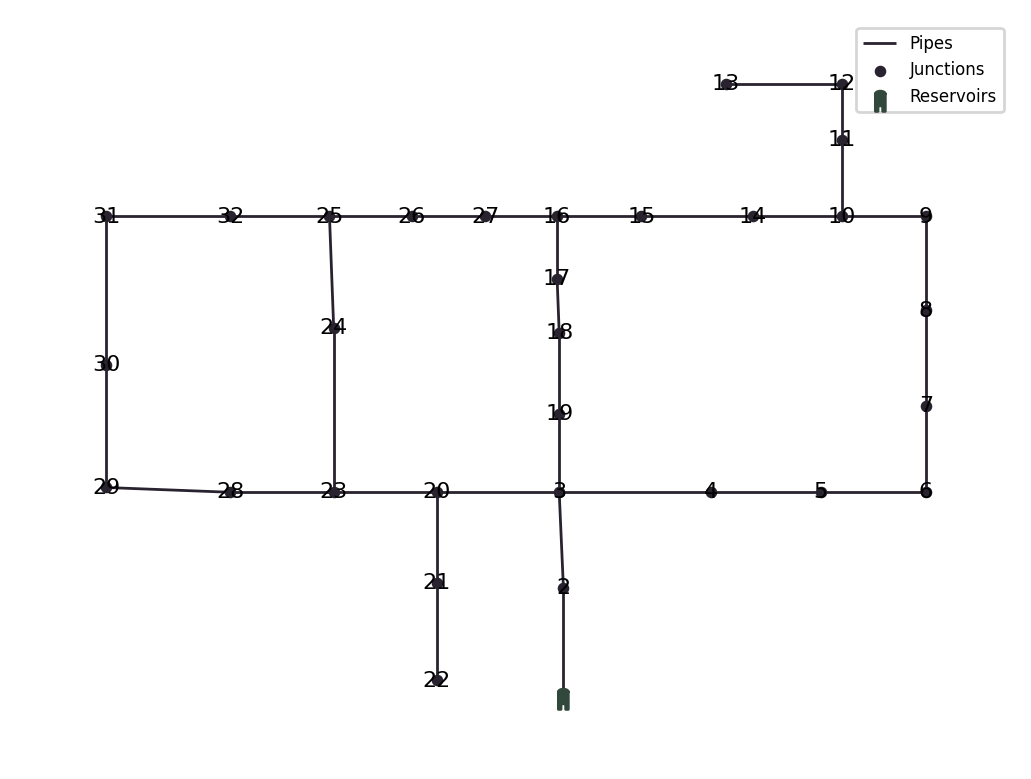

In [5]:
from epyt_flow.visualization import ScenarioVisualizer
vis = ScenarioVisualizer(sim)
vis.add_labels(["nodes"])
vis.show_plot(export_to_file="hanoi_nodes.pdf")

In [6]:
topo = sim.get_topology()

print(topo.nodes)
print(topo.edges)


['2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '1']
[('2', '1'), ('2', '3'), ('3', '4'), ('3', '19'), ('3', '20'), ('4', '5'), ('5', '6'), ('6', '7'), ('7', '8'), ('8', '9'), ('9', '10'), ('10', '11'), ('10', '14'), ('11', '12'), ('12', '13'), ('14', '15'), ('15', '16'), ('16', '17'), ('16', '27'), ('17', '18'), ('18', '19'), ('20', '21'), ('20', '23'), ('21', '22'), ('23', '24'), ('23', '28'), ('24', '25'), ('25', '26'), ('25', '32'), ('26', '27'), ('28', '29'), ('29', '30'), ('30', '31'), ('31', '32')]


In [7]:
# Show information associated with node "2"
print(topo.get_node_info("2"))

{'elevation': 30.0, 'coord': [5251.17, 5268.69], 'comment': '', 'type': 0, 'base_demand': 889.9815063476562}


Set simulation duration :

In [8]:
sim.set_general_parameters(simulation_duration=to_seconds(days=21))

Place sensors:

In [9]:
cl_sensor_locations = ['2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '1']
all_nodes = sim.sensor_config.nodes

sim.set_bulk_species_node_sensors({"Chlorine": cl_sensor_locations,
                                   # Also: Keep track of the contaminant
                                   "AsIII": all_nodes})   # Arsenite

Generate a contamination event

In [ ]:
import random

possible_nodes = ['2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '1']
species = "AsIII"
contamination_node = "3"
start_day = random.randint(3, 15)  
duration_days = random.randint(2, 5)  
injection_amount = random.randint(1, 100000)
source_type = EpanetConstants.EN_MASS


def generate_contamination_event(species: str, contamination_node: str, injection_amount: float, source_type: int, start_day: int, duration_days: int):
    """
    Function to generate a contamination event, which consists of an injection of a species at a node in the network.
    The contamination event is defined as an injection of a species at a specific node in the network, with a specified profile and duration.

    Parameters:
    species: id of the species being injected
    contamination_node: node id where the contamination occurs
    start_day: day of the start of the contamination event 
    duration_days: duration of the contamination event in days 
    injection_amount: amount of species injected 

    Returns:
    contamination_event: a SpeciesInjectionEvent object that represents the contamination event

    """
    
    contamination_event = SpeciesInjectionEvent(
        species_id=species,
        node_id=contamination_node,
        profile=np.array([injection_amount]),
        source_type=source_type,
        start_time=to_seconds(days=start_day),
        end_time=to_seconds(days=start_day + duration_days)
    )

    return contamination_event


event = generate_contamination_event(species, contamination_node, injection_amount, source_type, start_day, duration_days)
print(f"Generated contamination event: {event}")
sim.add_system_event(event)

Generated contamination event: start_time: 259200 end_time: 691200 species_id: AsIII node_id: 3 profile: [26635] source_type: 1


Run simulation:

In [11]:
scada_data = sim.run_simulation()

c:\Users\eline\Documents\Documents\university\Master 2\memoire\AI-for-Drinking-Water\env\Lib\site-packages\epyt_flow\simulation\scenario_simulator.py:2978: UserWarning: Failed to remove temporary file 'C:\Users\eline\AppData\Local\Temp\epytflow_MSX_79744f43-a70e-4880-bc20-090f738fd5fc.hyd'
  warnings.warn(f"Failed to remove temporary file '{hyd_export}'")


Plot simulation results :

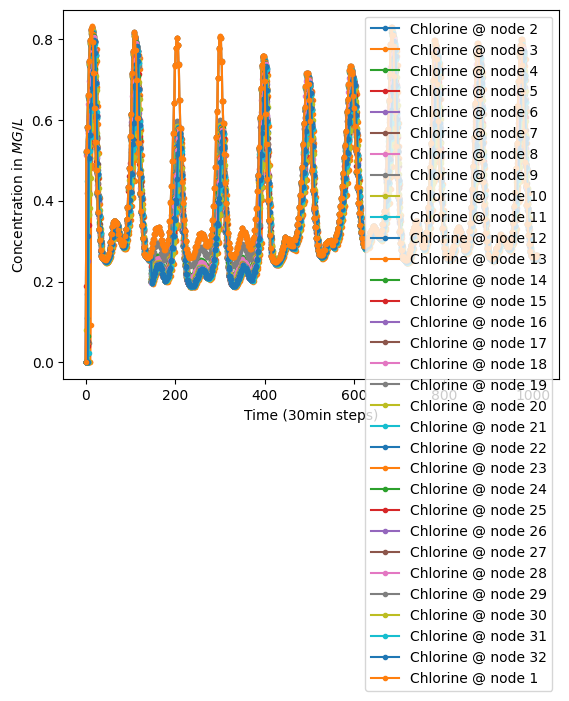

<Axes: xlabel='Time (30min steps)', ylabel='Concentration in $MG/L$'>

In [12]:
scada_data.plot_bulk_species_node_concentration({"Chlorine": cl_sensor_locations})

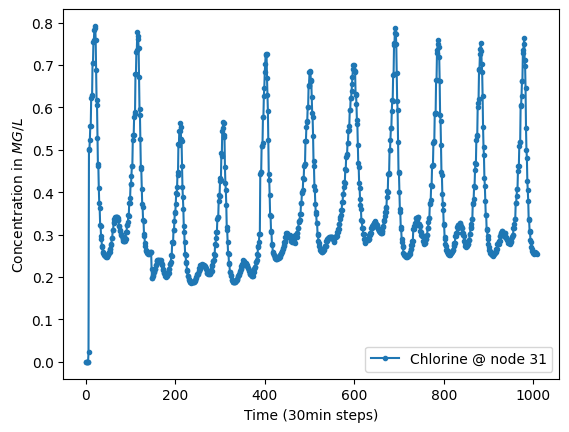

<Axes: xlabel='Time (30min steps)', ylabel='Concentration in $MG/L$'>

In [13]:
scada_data.plot_bulk_species_node_concentration({"Chlorine": ["31"]})

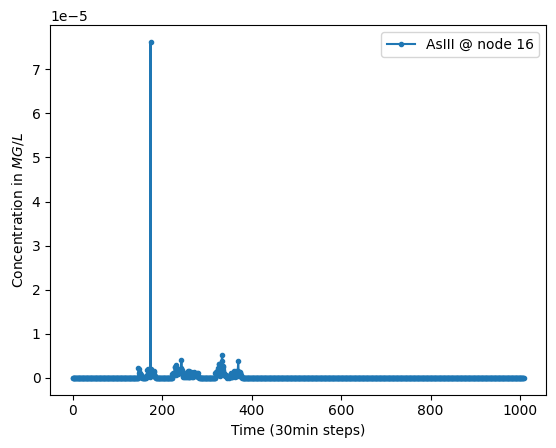

<Axes: xlabel='Time (30min steps)', ylabel='Concentration in $MG/L$'>

In [14]:
scada_data.plot_bulk_species_node_concentration({"AsIII": ["16"]})

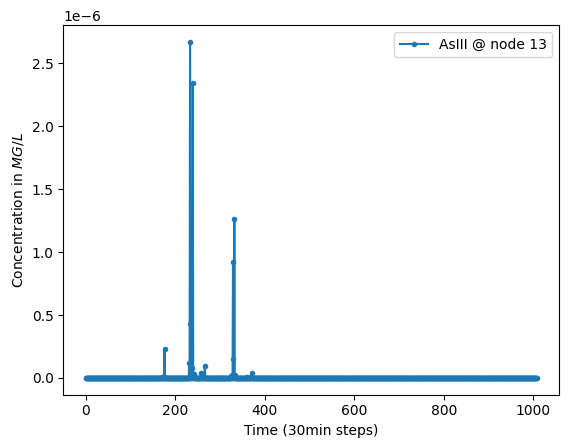

<Axes: xlabel='Time (30min steps)', ylabel='Concentration in $MG/L$'>

In [15]:
scada_data.plot_bulk_species_node_concentration({"AsIII": ["13"]})

Export data to csv format:

In [ ]:
# Export SCADA results 
df = scada_data.to_pandas_dataframe(export_raw_data=False)
df.to_csv("scada_data_conta_3_train_8.csv", index=False)


In [17]:
sim.close()